# 💡 한눈에 정리하는 머신러닝 기초: 비지도학습(Unsupervised Learning) 완전 정복

지도학습에 이어 이번에는 머신러닝의 또 다른 거대한 축, 비지도학습(Unsupervised Learning)을 복습해 봅시다.

비지도학습의 핵심은 **'정답(Label)이 없는 데이터'** 를 학습시킨다는 점입니다.

비지도학습은 목적에 따라 크게 두 가지 유형으로 나뉩니다.
- **클러스터링(군집화)**
- **차원 축소**

---


## Part 1. 클러스터링 (Clustering): "정답 없이 끼리끼리 모으기"

클러스터링은 데이터의 그룹(라벨) 정보가 없는 상태에서, **유사한 특성을 가진 데이터끼리 그룹(군집)으로 묶어주는 기법**입니다.

* **목표**: 군집(그룹) 간의 유사성은 최소화하고(서로 멀리 떨어뜨리고), 군집 내부 요소들의 유사성은 최대화(자기들끼리 똘똘 뭉치게) 하는 것입니다.
* **분류 방식**:
  * **하드 클러스터링 (Hard Clustering)**: "A 그룹에 속한다. 속하지 않는다." 처럼 특정 군집에 속하는지 여부를 이진법(0 또는 1)으로 결정.
  * **소프트 클러스터링 (Soft Clustering)**: "너는 A 그룹일 확률이 80%, B 그룹일 확률이 20%야" 처럼 각 군집에 속할 확률(가중치)로 유연하게 표현.



### 1-1. K-Means 클러스터링 (K-Means Clustering)

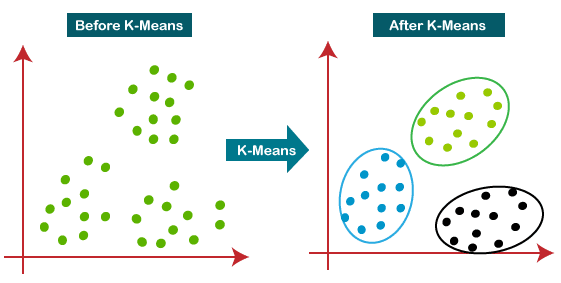

* **특징**: 데이터를 사용자가 지정한 **K개의 군집**으로 나누는 대표적인 하드 클러스터링 알고리즘입니다.
* **작동 방식**: 중심점을 임의로 잡고 이동시키는 과정을 최적의 K값을 찾을 때까지(비용 함수 그래프의 기울기가 급격히 꺾이는 'Elbow Point'가 나타날 때까지) 반복합니다.

* **⚠️ 꼭 기억할 점**:
  * 거리 기반 알고리즘이므로 변수들의 단위를 맞춰주는 **스케일링(Scaling)** 작업이 필수.
  * 비교적 단순한 계산 덕분에 **대용량 데이터**에도 효율적으로 적용할 수 있음.
  * 다만, 평균값을 기준으로 중심을 잡기 때문에 **이상치(Outlier)에 매우 민감**하게 반응.
  * 초기 중심점 위치에 따라 결과가 달라질 수 있어, 여러 번 반복 수행 -> 가장 빈번, 안정적으로 등장하는 군집 구성을 선택.

In [ ]:
from sklearn.cluster import KMeans

# 1. 모델 생성 및 학습
# 1-1. 모델 생성
# init='random'으로 초기화 방식 지정, n_clusters로 군집 수 설정
model_kmeans = KMeans(init='random', n_clusters=3, random_state=100)

# 1-2. 모델 학습
model_kmeans.fit(X)


# 2. 결과 확인
cluster_labels = model_kmeans.labels_       # 각 데이터가 속한 군집 번호 반환
centroids = model_kmeans.cluster_centers_   # 진짜 군집 중심점(Centroid) 좌표 반환

---

### 1-2. GMM (Gaussian Mixture Model)

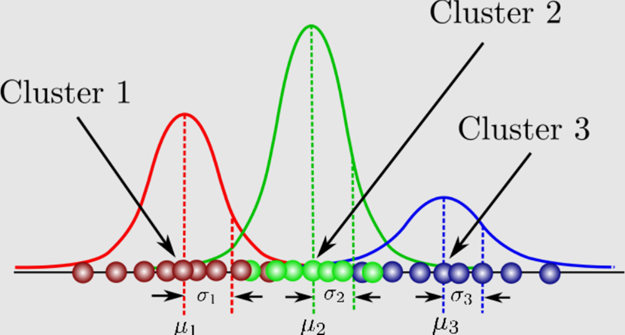

* **특징**: 데이터가 여러 개의 가우시안 분포(정규분포)가 혼합된 형태로부터 생성되었다고 가정하는 대표적인 **소프트 클러스터링** 알고리즘입니다.
* **작동 방식** (동시 진행이 불가능하여 다음 2단계를 번갈아 반복):
  1. **클러스터 형태 추정**: 각 군집의 평균과 분산(형태)을 파악합니다.
  2. **소속 확률 계산**: 개별 데이터가 해당 클러스터에 속할 확률을 계산합니다.


* **⚠️ 꼭 기억할 점**:
  * 확률 분포를 복잡하게 계산하기 때문에 **대용량 데이터에 적용하기엔 계산량이 너무 많아 적합하지 않음**.
  * K-Means와 마찬가지로 극단적인 **이상치에 취약**한 면모를 보임.

In [ ]:
from sklearn.mixture import GaussianMixture

# 1. 모델 생성 및 학습
# 1-1. 모델 생성
# n_components로 생성할 군집(성분)의 개수를 설정.
model_gmm = GaussianMixture(n_components=3, random_state=100)

# 1-2. 모델 학습
model_gmm.fit(X)


# 2. 결과 확인 (각 데이터가 어떤 군집에 속할지 최종 예측값 반환)
gmm_labels = model_gmm.predict(X)

---

### 1-3. 클러스터링 평가지표

지도학습과 달리 채점할 수 있는 '정답 라벨'이 없으므로 오차율을 계산할 수 없습니다. 대신 군집 간의 거리와 군집 내부의 오밀조밀함(지름, 분산)을 고려해 성능을 간접 평가합니다.

#### ① 던 인덱스 (Dunn Index)

군집 간 거리의 최솟값을 군집 내 데이터들 간 거리의 최댓값(지름)으로 나눈 비율입니다. 분자가 클수록(군집끼리 멀고), 분모가 작을수록(군집 내부끼리 잘 뭉칠수록) 성능이 우수함을 의미합니다.


$$\text{Dunn Index} = \frac{\text{군집 간 거리의 최솟값}}{\text{군집 내 요소 간 거리의 최댓값}}$$

* **판단**: Dunn Index 값이 **크면 클수록** 군집화가 잘 되었다고 판단합니다.

#### ② 실루엣 지표 (Silhouette Coefficient)

개별 데이터가 자신이 속한 군집 내 다른 데이터와 얼마나 가깝고, 가장 가까운 인접 군집과는 얼마나 멀리 떨어져 있는지를 계산하여 수치화한 지표입니다.

* **판단**: **-1에서 1 사이의 값**을 가지며, **1에 가까울수록** 군집화가 아주 이상적으로 잘 되었다고 평가합니다.

---


## Part 2. 차원 축소 (Dimensionality Reduction): "핵심만 남기고 덜어내기"

데이터 분석에서 **'차원(Dimension)'은 곧 컬럼(특성, Feature)의 개수**를 뜻합니다. 컬럼이 수천, 수만 개에 달하는 고차원 데이터를 다룰 때 차원 축소를 활용합니다.

* **목표**: 데이터를 가장 잘 설명할 수 있는 핵심적인 성분만 남겨 차원을 대폭 줄임으로써, **모델의 학습 속도를 개선하고 데이터를 효율적으로 압축**하는 것입니다.
* **고차원의 저주**: 차원이 너무 높아지면 학습에 필요한 데이터 수가 기하급수적으로 늘어납니다. 만약 데이터가 충분하지 않은 상태에서 차원만 높다면 모델이 빈 공간의 사소한 노이즈까지 학습하게 되어 심각한 과적합(Overfitting)이 발생합니다.

---


### 2-1. 주성분 분석 (PCA - Principal Component Analysis)

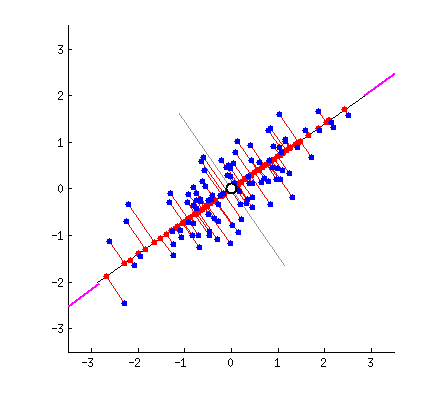

* **특징**: 고차원 데이터의 정보를 최대한 보존하면서(분산을 최대화하면서) 원본 데이터를 가장 잘 설명하는 독립적인 축(**주성분**)들을 찾아내는 선형 차원 축소 기법입니다.
* **작동 방식**: 데이터의 흩어짐(분산)이 가장 큰 방향으로 첫 번째 축을 찾고, 이 축과 직교하는 방향 중 분산이 가장 큰 두 번째 축을 찾아 차원을 축소합니다.

* **⚠️ 꼭 기억할 점**:
  * 변수 간의 스케일 차이가 축을 찾는 데 영향을 주므로 학습 전에 **반드시 스케일링을 진행**.
  * 여러 컬럼을 수학적으로 결합하여 전혀 새로운 성분(PC)을 만들어내기 때문에, 축소 후에는 기존 피처들이 가졌던 직관적인 의미를 잃어버려 **결과 해석이 다소 어려움**.

In [ ]:
from sklearn.decomposition import PCA

# n_components로 축소하여 남길 차원(성분)의 수를 지정.
pca = PCA(n_components=2)

# 모델 학습
pca.fit(X)

#데이터 변환(축소)을 차례로 진행.
X_pca = pca.transform(X)

---

### 2-2. t-SNE (t-Distributed Stochastic Neighbor Embedding)

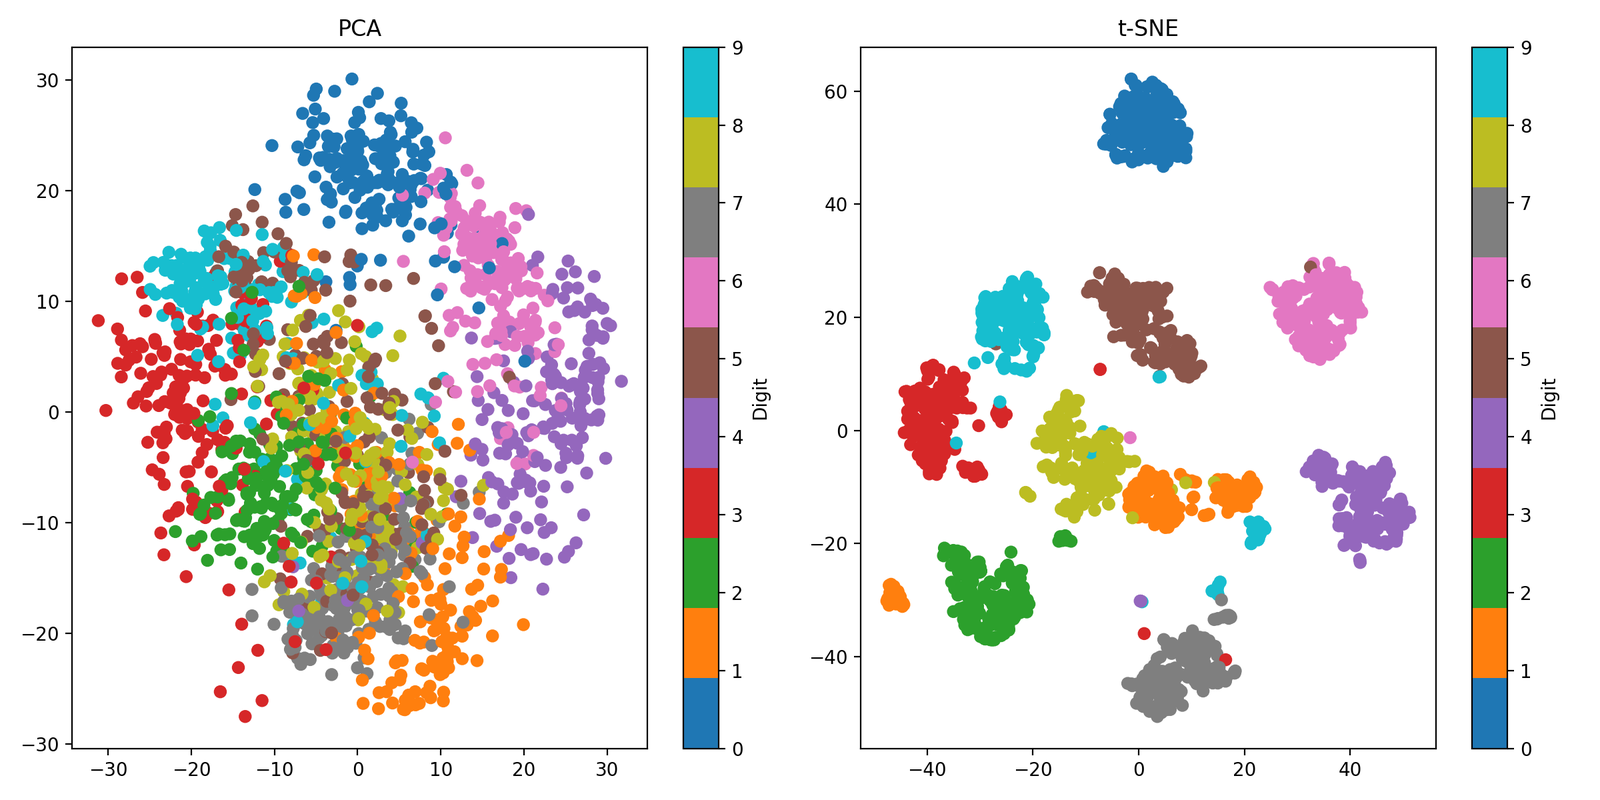

* **특징**: 고차원 공간에서 **가까이 있는 데이터 포인트들 간의 거리(유사도)를 저차원 공간에서도 최대한 가깝게 유지**하도록 설계된 비선형 차원 축소 기법입니다. 주로 데이터 시각화 목적으로 애용됩니다.

* **작동 방식**:
  1. 고차원 데이터 포인트 쌍의 유사도를 확률 분포로 변환.
  2. 저차원 공간에서도 동일한 유사도 확률 분포를 갖도록 데이터를 점진적으로 재배치.


* **⚠️ 꼭 기억할 점**:
  * 수학적 구조상 학습 데이터 전체를 놓고 한 번에 계산해야 하므로, `fit()`과 `transform()`을 분리해서 실행하기 어렵고 항상 **`fit_transform()`을 사용하여 한 번에 처리**합니다.

In [ ]:
from sklearn.manifold import TSNE

# n_components로 축소할 저차원 크기를 지정. (시각화용이므로 주로 2차원)
tsne = TSNE(n_components=2, random_state=100)

# t-SNE는 학습과 차원 축소 변환을 한 번에 실행.
X_tsne = tsne.fit_transform(X)

---

## 📝 마치며

비지도학습은 정답 레이블이 주어지지 않기 때문에 알고리즘의 성격과 데이터의 구조를 파악하는 안목이 훨씬 중요합니다.

* 직관적으로 데이터를 그룹화해보고 싶다면 **K-Means**, 확률적으로 유연하게 묶어보고 싶다면 **GMM**을 고려해 보세요.
* 컬럼 수가 너무 많아 학습이 느리다면 **PCA**로 정보를 요약하고, 고차원 군집들이 실제로 어떻게 뭉쳐있는지 눈으로 직접 그려보고 싶다면 **t-SNE**를 활용해 시각화해보는 습관을 들이는 것이 좋습니다.